[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/catboost_quantile_multiquantile_cqr.ipynb)

# CatBoost quantile bands: what they cover, and what conformalizing changes

A quantile loss fits one level of the conditional distribution. `MultiQuantile` fits a grid of them
in one model. Taking the outer pair as a 90% prediction interval is the obvious next step, and this
notebook measures what that interval covers on rows the model has not seen.

Three datasets from the conformalized quantile regression paper (Romano, Patterson and Candes,
NeurIPS 2019), spanning two orders of magnitude in size: concrete at 1,030 rows, bike at 10,886,
casp at 45,730, read from the copies in the authors' repository. bike's datetime column is
expanded into hour, day of week, month and year.

Three ways to build the same band are compared throughout, because they are not equivalent:

- two separate `Quantile` models, one per level
- `MultiQuantile` on the outer pair
- `MultiQuantile` on ten levels, taking the outer pair from it

Runtime is about fifteen minutes on a laptop CPU and longer on a free Colab runtime, so the tables
below are worth reading before deciding to run it.

In [1]:
try:
    import catboost
except ImportError:
    !pip install -q catboost

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

## Setup

One place for every choice the experiment makes. Coverage uses eight seeds; the ten-level
comparisons cost ten fits each and use five.

In [3]:
ALPHA = 0.1
LO, HI = ALPHA / 2, 1 - ALPHA / 2
PAIR = [LO, HI]
TEN = list(np.round(np.linspace(0.05, 0.95, 10), 2))
CONFIGS = {"300/0.05/d4": (300, 0.05, 4),
           "500/0.1/d6": (500, 0.1, 6),
           "1000/0.05/d6": (1000, 0.05, 6)}
COVER_SEEDS, GRID_SEEDS = range(8), range(5)
SIZES = [500, 1000, 2000, 5000, 10000, 25000]
CFG_LABEL = {k: f"{i:,} iterations, depth {d}" for k, (i, lr, d) in CONFIGS.items()}
BASE = "https://raw.githubusercontent.com/yromano/cqr/master/datasets/"

In [4]:
def concrete():
    d = pd.read_csv(BASE + "Concrete_Data.csv")
    return d.iloc[:, :-1], d.iloc[:, -1]


def bike():
    d = pd.read_csv(BASE + "bike_train.csv")
    t = pd.DatetimeIndex(d.datetime)
    d = d.assign(hour=t.hour, day=t.dayofweek, month=t.month, year=t.year)
    return d.drop(columns=["datetime", "casual", "registered", "count"]), d["count"]


def casp():
    d = pd.read_csv(BASE + "CASP.csv")
    return d.iloc[:, 1:], d.iloc[:, 0]


DATA = {"concrete": concrete(), "bike": bike(), "casp": casp()}

pd.DataFrame([{"dataset": k, "rows": len(y), "features": X.shape[1],
               "test rows": int(np.ceil(0.2 * len(y))), "target sd": round(y.std(), 2)}
              for k, (X, y) in DATA.items()])

,dataset,rows,features,test rows,target sd
0,concrete,1030,8,206,16.71
1,bike,10886,12,2178,181.14
2,casp,45730,9,9146,6.12


## The pinball loss

The loss charges τ per unit when the prediction lands below the truth and 1 − τ when it lands
above. Nothing else about the method is asymmetric.

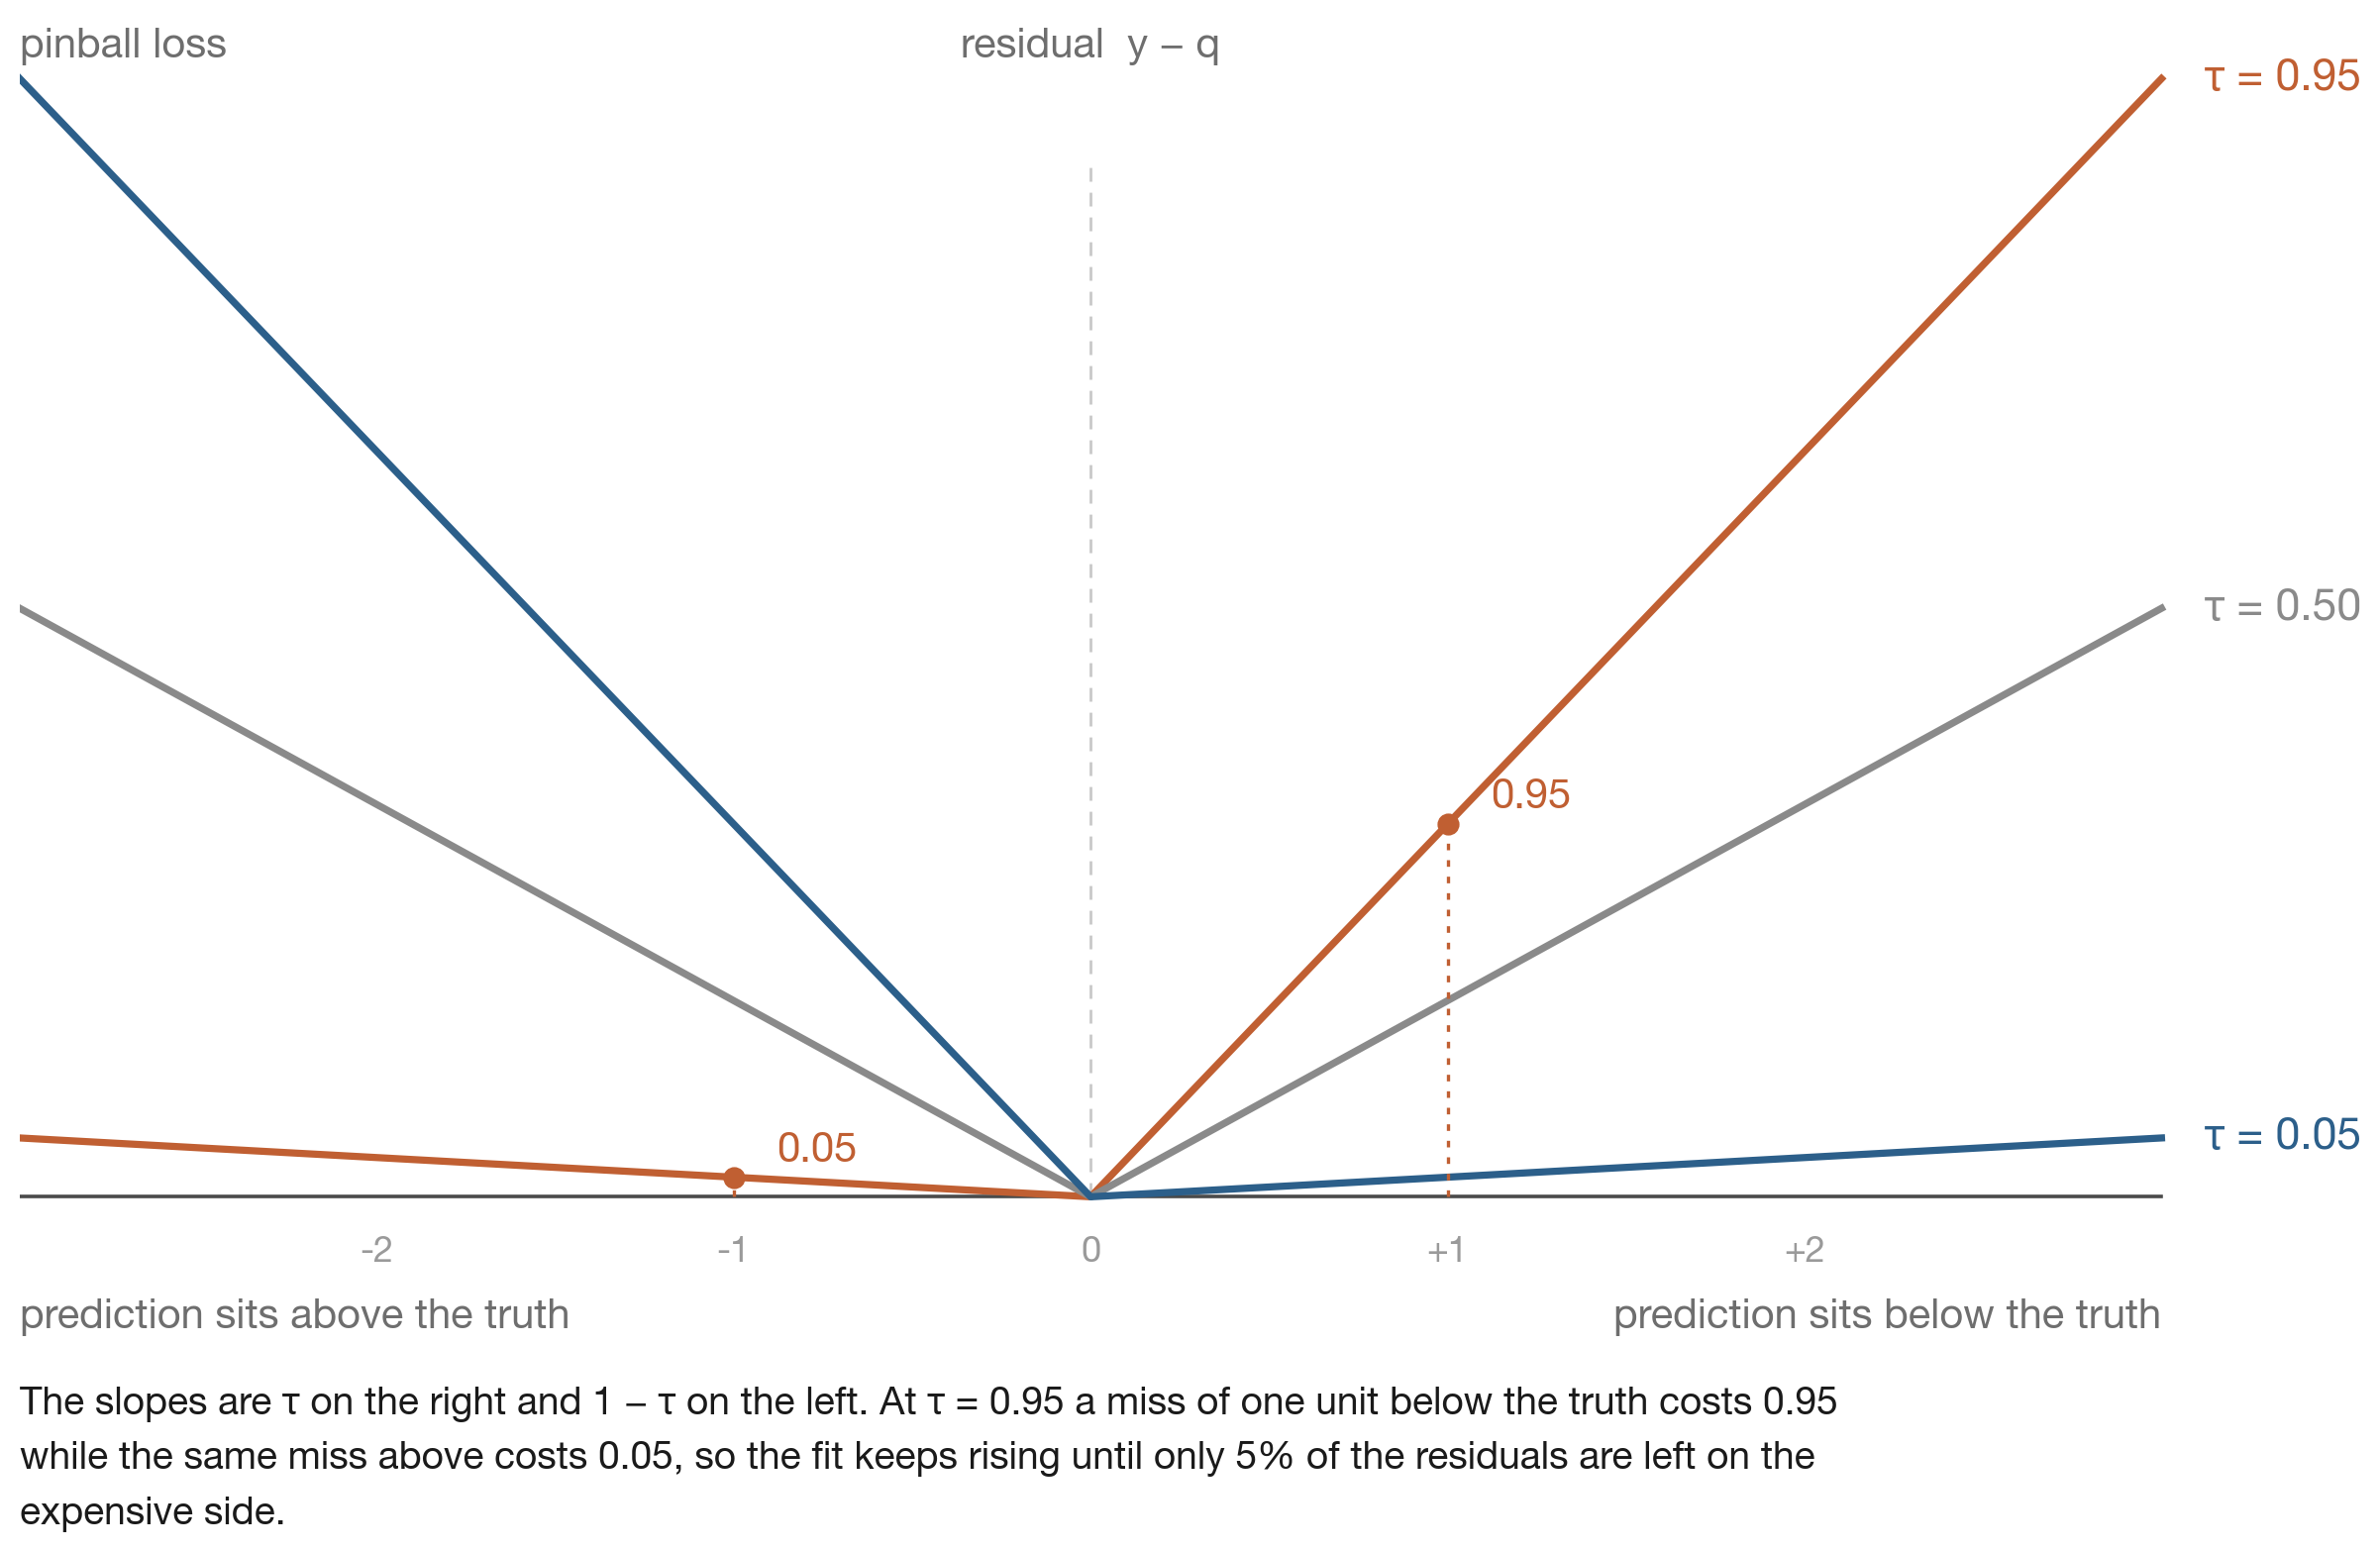

In [5]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_E, CORAL_E, GREY_E = "#2C5F8A", "#C05F32", "#8a8a8a"
INK, TEXT_MUTED, TEXT_FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"

TAUS = [(0.95, CORAL_E), (0.50, GREY_E), (0.05, BLUE_E)]
XMIN, XMAX, YMAX = -3.0, 3.0, 3.0
u = np.linspace(XMIN, XMAX, 601)

fig = plt.figure(figsize=(13.8, 8.6), dpi=200)
ax = fig.add_axes([0.055, 0.17, 0.79, 0.76])
ax.set_xlim(XMIN, XMAX + 0.05)
ax.set_ylim(-0.30, YMAX)
ax.axis("off")
ax.add_line(Line2D([XMIN, XMAX], [0, 0], color="#4a4a4a", lw=1.3, zorder=2))
ax.add_line(Line2D([0, 0], [0, YMAX - 0.35], color="#c9c9c9", lw=1.0, ls=(0, (5, 4)), zorder=1))

for tau, colour in TAUS:
    ax.plot(u, np.where(u > 0, tau * u, (1 - tau) * -u), color=colour, lw=2.6, zorder=3)
    ax.text(XMAX + 0.12, tau * XMAX, f"τ = {tau:.2f}", ha="left", va="center",
            fontsize=16, color=colour)

for side, height in ((1, 0.95), (-1, 0.05)):
    ax.add_line(Line2D([side, side], [0, height], color=CORAL_E, lw=1.2, ls=(0, (2, 3)), zorder=4))
    ax.plot([side], [height], "o", ms=7, color=CORAL_E, zorder=5)
    ax.text(side + 0.12, height + 0.02, f"{height:.2f}", ha="left", va="bottom",
            fontsize=15, color=CORAL_E)

for tick in (-2, -1, 0, 1, 2):
    ax.text(tick, -0.10, f"{tick:+g}" if tick else "0", ha="center", va="top",
            fontsize=13, color=TEXT_FAINT)
ax.text(0, YMAX - 0.02, "residual  y − q", ha="center", va="top",
        fontsize=15, color=TEXT_MUTED)
ax.text(XMIN, YMAX - 0.02, "pinball loss", ha="left", va="top", fontsize=15, color=TEXT_MUTED)
ax.text(XMIN, -0.26, "prediction sits above the truth", ha="left", va="top",
        fontsize=15, color=TEXT_MUTED)
ax.text(XMAX, -0.26, "prediction sits below the truth", ha="right", va="top",
        fontsize=15, color=TEXT_MUTED)
fig.text(0.055, 0.085,
         "The slopes are τ on the right and 1 − τ on the left. At τ = 0.95 a "
         "miss of one unit below the truth costs 0.95\nwhile the same miss above costs 0.05, so "
         "the fit keeps rising until only 5% of the residuals are left on the\nexpensive side.",
         ha="left", va="center", fontsize=14, color=INK, linespacing=1.7)
fig.savefig("catboost_quantile_pinball.png", facecolor="white")
plt.show()

## Fitting the levels

`fit_joint` and `fit_separate` are the only place the three arms differ: one model asked for
several levels, or one model per level.

In [6]:
def fit(X, y, qs, seed, cfg):
    iters, lr, depth = cfg
    loss = (f"Quantile:alpha={qs[0]}" if len(qs) == 1
            else f"MultiQuantile:alpha={','.join(map(str, qs))}")
    return CatBoostRegressor(loss_function=loss, iterations=iters, learning_rate=lr,
                             depth=depth, random_seed=seed, verbose=0).fit(X, y)


def fit_joint(X, y, qs, seed, cfg):
    return [fit(X, y, qs, seed, cfg)]


def fit_separate(X, y, qs, seed, cfg):
    return [fit(X, y, [q], seed, cfg) for q in qs]


def predict_levels(models, Xte):
    if len(models) == 1:
        return models[0].predict(Xte).reshape(len(Xte), -1)
    return np.column_stack([m.predict(Xte) for m in models])


ARMS = [("separate pair", PAIR, fit_separate),
        ("MultiQuantile pair", PAIR, fit_joint),
        ("MultiQuantile ten", TEN, fit_joint)]

## Conformalizing the band

Following Romano et al.: the score is `max(q_lo - y, y - q_hi)` (eq. 6), the correction is the
k-th smallest score with `k = ceil((1 - alpha)(n + 1))` (eq. 7), and the interval widens by that
amount on both sides (eq. 8).

Writing eq. 7 as a quantile level needs care. `(1 - alpha) * (1 + 1/n)` with `method="higher"`
gives the k-th smallest. Applying `ceil` before dividing takes the one after it, which is
conservative but not what the paper says.

In [7]:
def shift(lo, hi, y):
    e = np.maximum(lo - y, y - hi)
    n = len(e)
    return np.quantile(e, min(1.0, (1 - ALPHA) * (1 + 1 / n)), method="higher")


def cover(lo, hi, y):
    return 100 * ((y >= lo) & (y <= hi)).mean()


def arm(Xp, yp, Xte, yte, qs, seed, cfg, strategy):
    """Raw band on the whole pool, then the same recipe split in half to calibrate."""
    i, j = qs.index(LO), qs.index(HI)
    p = predict_levels(strategy(Xp, yp, qs, seed, cfg), Xte)
    rc = cover(p[:, i], p[:, j], yte)
    Xtr, Xca, ytr, yca = train_test_split(Xp, yp, test_size=0.5, random_state=seed)
    half = strategy(Xtr, ytr, qs, seed, cfg)
    pc, pt = predict_levels(half, Xca), predict_levels(half, Xte)
    q = shift(pc[:, i], pc[:, j], yca.values)
    hc = cover(pt[:, i], pt[:, j], yte)
    cc = cover(pt[:, i] - q, pt[:, j] + q, yte)
    return {"raw": rc, "half": hc, "cqr": cc}

## What the band covers

Every arm is evaluated on the same held-out fifth of the data. `raw` trains on the rest, `half`
trains on half of it, and `cqr` conformalizes that halved model on the other half. Comparing `raw`
with `cqr` therefore mixes the correction with the training rows given up for calibration, which
is why `half` is reported next to them.

In [8]:
cover_rows = []
for name, (X, y) in DATA.items():
    for s in COVER_SEEDS:
        Xp, Xte, yp, yte = train_test_split(X, y, test_size=0.2, random_state=s)
        for cname, cfg in CONFIGS.items():
            for aname, qs, strategy in ARMS:
                cover_rows.append({"data": name, "config": cname, "arm": aname, "seed": s,
                                   **arm(Xp, yp, Xte, yte, qs, s, cfg, strategy)})
cover_df = pd.DataFrame(cover_rows)
cover_df.pivot_table(index=["data", "config"], columns="arm",
                     values=["raw", "half", "cqr"]).round(2)

cqr                                  \
arm                   MultiQuantile pair MultiQuantile ten separate pair   
data     config                                                            
bike     1000/0.05/d6              90.12             89.98         90.36   
         300/0.05/d4               90.09             90.04         89.86   
         500/0.1/d6                89.86             90.19         90.00   
casp     1000/0.05/d6              89.99             89.99         89.95   
         300/0.05/d4               90.21             90.18         90.18   
         500/0.1/d6                90.06             90.15         90.03   
concrete 1000/0.05/d6              91.32             90.41         89.87   
         300/0.05/d4               89.93             90.11         89.62   
         500/0.1/d6                90.41             89.68         89.75   

                                    half                                  \
arm                   MultiQuantile pair MultiQuantile ten separate pair   
data     config                                                            
bike     1000/0.05/d6              82.80             74.67         82.01   
         300/0.05/d4               88.21             88.35         87.74   
         500/0.1/d6                82.66             74.49         80.95   
casp     1000/0.05/d6              84.13             82.51         84.41   
         300/0.05/d4               89.26             89.29         89.17   
         500/0.1/d6                84.42             82.65         84.44   
concrete 1000/0.05/d6              62.01             43.39         58.80   
         300/0.05/d4               75.79             68.99         75.67   
         500/0.1/d6                61.83             44.05         59.04   

                                     raw                                  
arm                   MultiQuantile pair MultiQuantile ten separate pair  
data     config                                                           
bike     1000/0.05/d6              85.70             80.99         84.50  
         300/0.05/d4               89.35             89.51         89.05  
         500/0.1/d6                85.62             80.96         84.66  
casp     1000/0.05/d6              86.59             86.24         86.38  
         300/0.05/d4               89.80             89.74         89.70  
         500/0.1/d6                86.46             86.17         86.46  
concrete 1000/0.05/d6              72.69             55.58         70.87  
         300/0.05/d4               81.61             79.98         81.74  
         500/0.1/d6                73.06             57.46         72.15

In [9]:
means = cover_df.groupby(["data", "config", "arm"])["raw"].mean()
print(f"seed-averaged raw bands reaching 90%: {(means >= 90).sum()} of {len(means)}")
print(f"they run from {means.min():.2f}% to {means.max():.2f}%")
print(f"single runs reached {cover_df['raw'].max():.2f}%")
print()
print("conformalized coverage, by dataset:")
print(cover_df.groupby("data")["cqr"].agg(["mean", "std", "min", "max"]).round(2).to_string())

seed-averaged raw bands reaching 90%: 0 of 27
they run from 55.58% to 89.80%
single runs reached 90.27%

conformalized coverage, by dataset:
           mean   std    min    max
data                               
bike      90.06  0.55  88.48  91.32
casp      90.08  0.29  89.37  90.87
concrete  90.12  2.64  83.98  95.15


Two effects sit in that table.

How hard the trees are fitted moves coverage the most, and it moves it the same way on every
dataset. The quantile heads reach their levels on the training rows; on new rows the residuals are
larger, so the band is too narrow.

Asking one model for ten levels costs extra, but only once the fit is hard. `MultiQuantile` on the
pair and two separate models agree closely everywhere, so the penalty comes from one tree structure
serving ten pinball gradients rather than from the loss itself.

The conformalized numbers centre on the nominal level on all three datasets. The guarantee is
marginal over both draws, so the spread around it is a finite-sample matter on either side:
concrete calibrates on 412 rows and measures on 206, against 18,292 and 9,146 for casp.

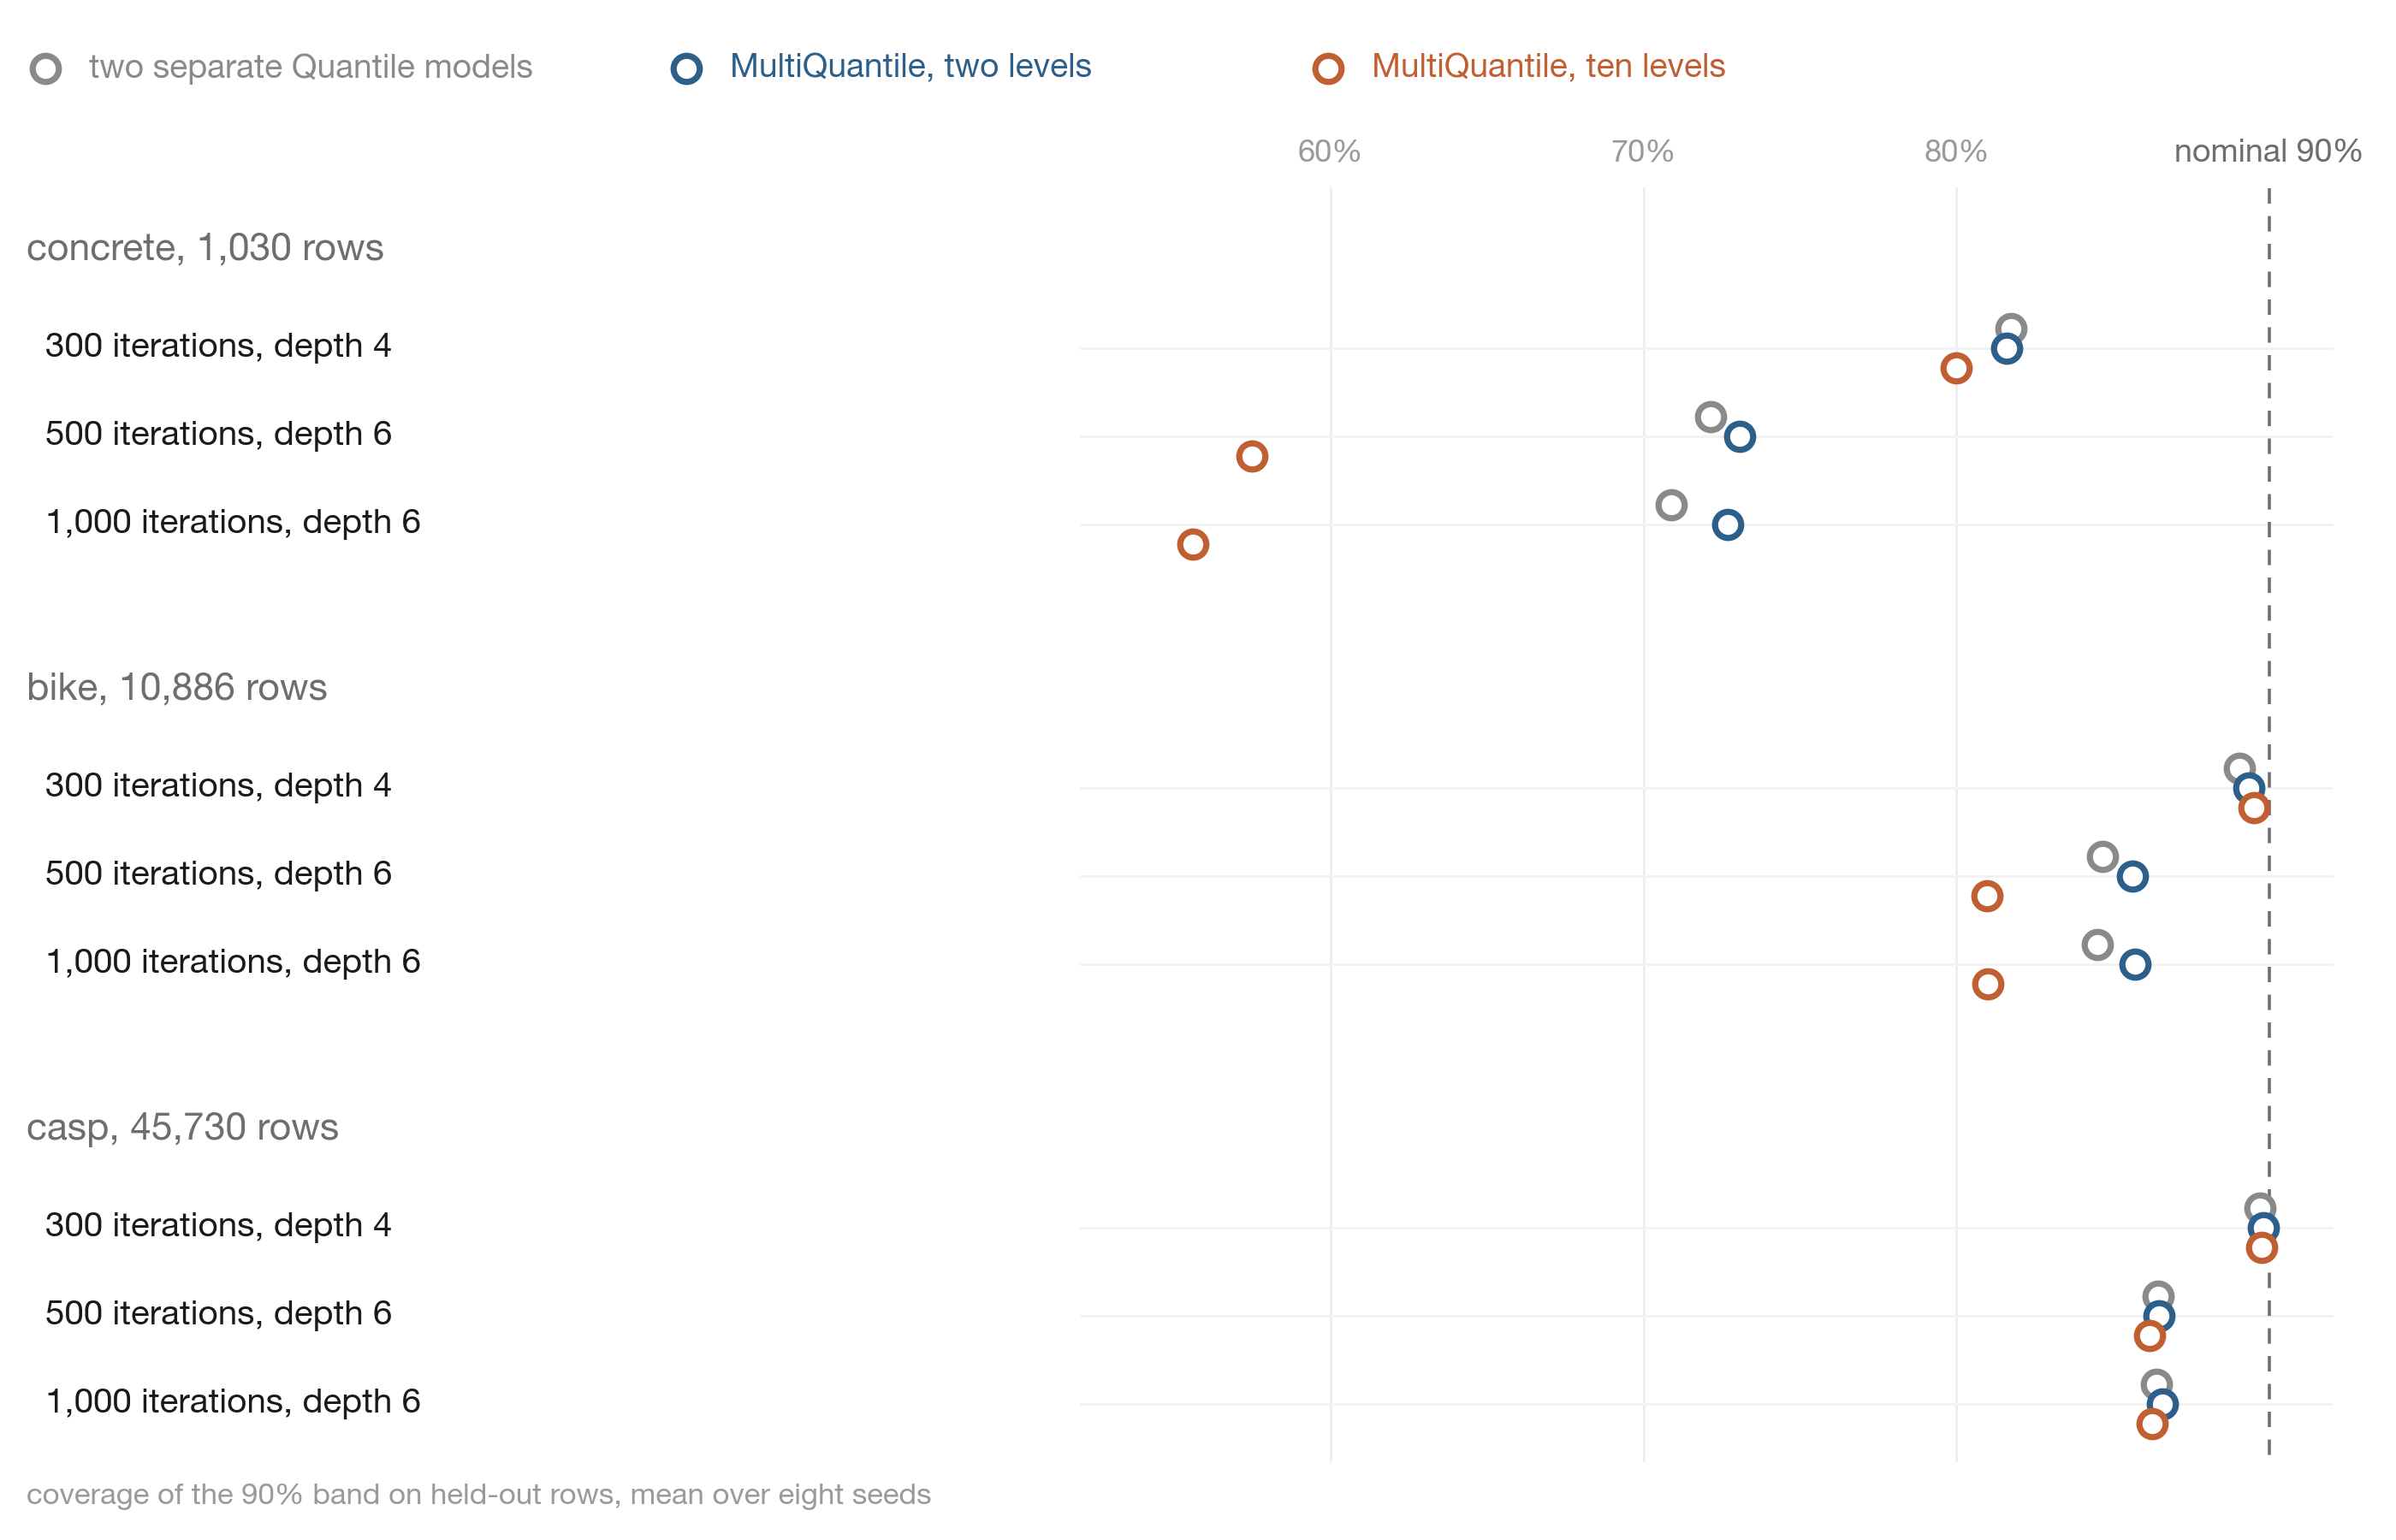

In [10]:
ROWS = {k: f"{k}, {len(v[1]):,} rows" for k, v in DATA.items()}
ARM_STYLE = {"separate pair": (GREY_E, "two separate Quantile models"),
             "MultiQuantile pair": (BLUE_E, "MultiQuantile, two levels"),
             "MultiQuantile ten": (CORAL_E, "MultiQuantile, ten levels")}
XL, XR, LEFT = 52.0, 92.0, 18.0
OFFSETS = (-0.19, 0.0, 0.19)
points, heads, cursor = [], [], 0.9
for name in DATA:
    heads.append((cursor, ROWS[name]))
    cursor += 0.95
    for cname in CONFIGS:
        points.append((cursor, CFG_LABEL[cname],
                       [(means[(name, cname, a)], ARM_STYLE[a][0], dy)
                        for (a, _, _), dy in zip(ARMS, OFFSETS)]))
        cursor += 0.85
    cursor += 0.75
YTOP = points[-1][0] + 1.15
GUIDE = points[-1][0] + 0.55

fig = plt.figure(figsize=(13.8, 8.8), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(LEFT, XR + 1.5)
ax.set_ylim(YTOP, -1.35)
ax.axis("off")
ax.add_line(Line2D([90, 90], [0.30, GUIDE], color="#6e6e6e", lw=1.3,
                   ls=(0, (5, 4)), zorder=1))
ax.text(90, 0.10, "nominal 90%", ha="center", va="bottom", fontsize=13.5, color=TEXT_MUTED)
for tick in (60, 70, 80):
    ax.add_line(Line2D([tick, tick], [0.30, GUIDE], color="#ededed", lw=1.0, zorder=0))
    ax.text(tick, 0.10, f"{tick}%", ha="center", va="bottom", fontsize=13, color=TEXT_FAINT)
for cy, label in heads:
    ax.text(LEFT + 0.3, cy, label, ha="left", va="center", fontsize=16, color=TEXT_MUTED)
for cy, label, vals in points:
    ax.add_line(Line2D([XL, XR], [cy] * 2, color="#f2f2f2", lw=1.0, zorder=0))
    ax.text(LEFT + 0.9, cy, label, ha="left", va="center", fontsize=14.5, color=INK)
    for v, colour, dy in vals:
        ax.plot([v], [cy + dy], "o", ms=11, color=colour, zorder=4,
                markerfacecolor="white", markeredgewidth=2.6)
for i, (colour, label) in enumerate(ARM_STYLE.values()):
    ax.plot([LEFT + 0.9 + i * 20.5], [-0.85], "o", ms=11, color=colour,
            markerfacecolor="white", markeredgewidth=2.6, clip_on=False)
    ax.text(LEFT + 2.3 + i * 20.5, -0.85, label, ha="left", va="center",
            fontsize=14, color=colour, clip_on=False)
ax.text(LEFT + 0.3, YTOP - 0.25,
        "coverage of the 90% band on held-out rows, mean over eight seeds",
        ha="left", va="center", fontsize=12.5, color=TEXT_FAINT)
fig.savefig("catboost_quantile_arms.png", facecolor="white")
plt.show()

## How much of it is the number of rows

Same dataset, same settings, same held-out test set at every size. Only the training pool is
subsampled, so nothing but the number of training rows changes along the sweep. The conformalized
curve splits that pool in half, training on one half and calibrating on the other.

In [11]:
X, y = DATA["casp"]
size_rows = []
for s in COVER_SEEDS:
    Xp, Xte, yp, yte = train_test_split(X, y, test_size=0.2, random_state=s)
    for n in SIZES + [len(Xp)]:
        idx = Xp.sample(n, random_state=s).index if n < len(Xp) else Xp.index
        size_rows.append({"train rows": n, "seed": s,
                          **arm(Xp.loc[idx], yp.loc[idx], Xte, yte, PAIR, s,
                                CONFIGS["500/0.1/d6"], fit_separate)})
size_df = pd.DataFrame(size_rows)
size_summary = size_df.groupby("train rows")[["raw", "cqr"]].agg(["mean", "min", "max"])
size_summary.round(2)

raw                  cqr              
             mean    min    max   mean    min    max
train rows                                          
500         61.44  57.58  65.47  90.01  86.20  93.90
1000        67.62  64.30  71.99  89.98  89.34  90.67
2000        71.81  69.11  75.97  90.13  88.94  91.03
5000        78.82  76.83  80.60  90.08  89.25  90.68
10000       82.18  80.89  83.45  90.27  89.54  90.83
25000       85.59  85.23  86.03  89.97  89.42  90.40
36584       86.46  86.20  86.86  90.03  89.57  90.45

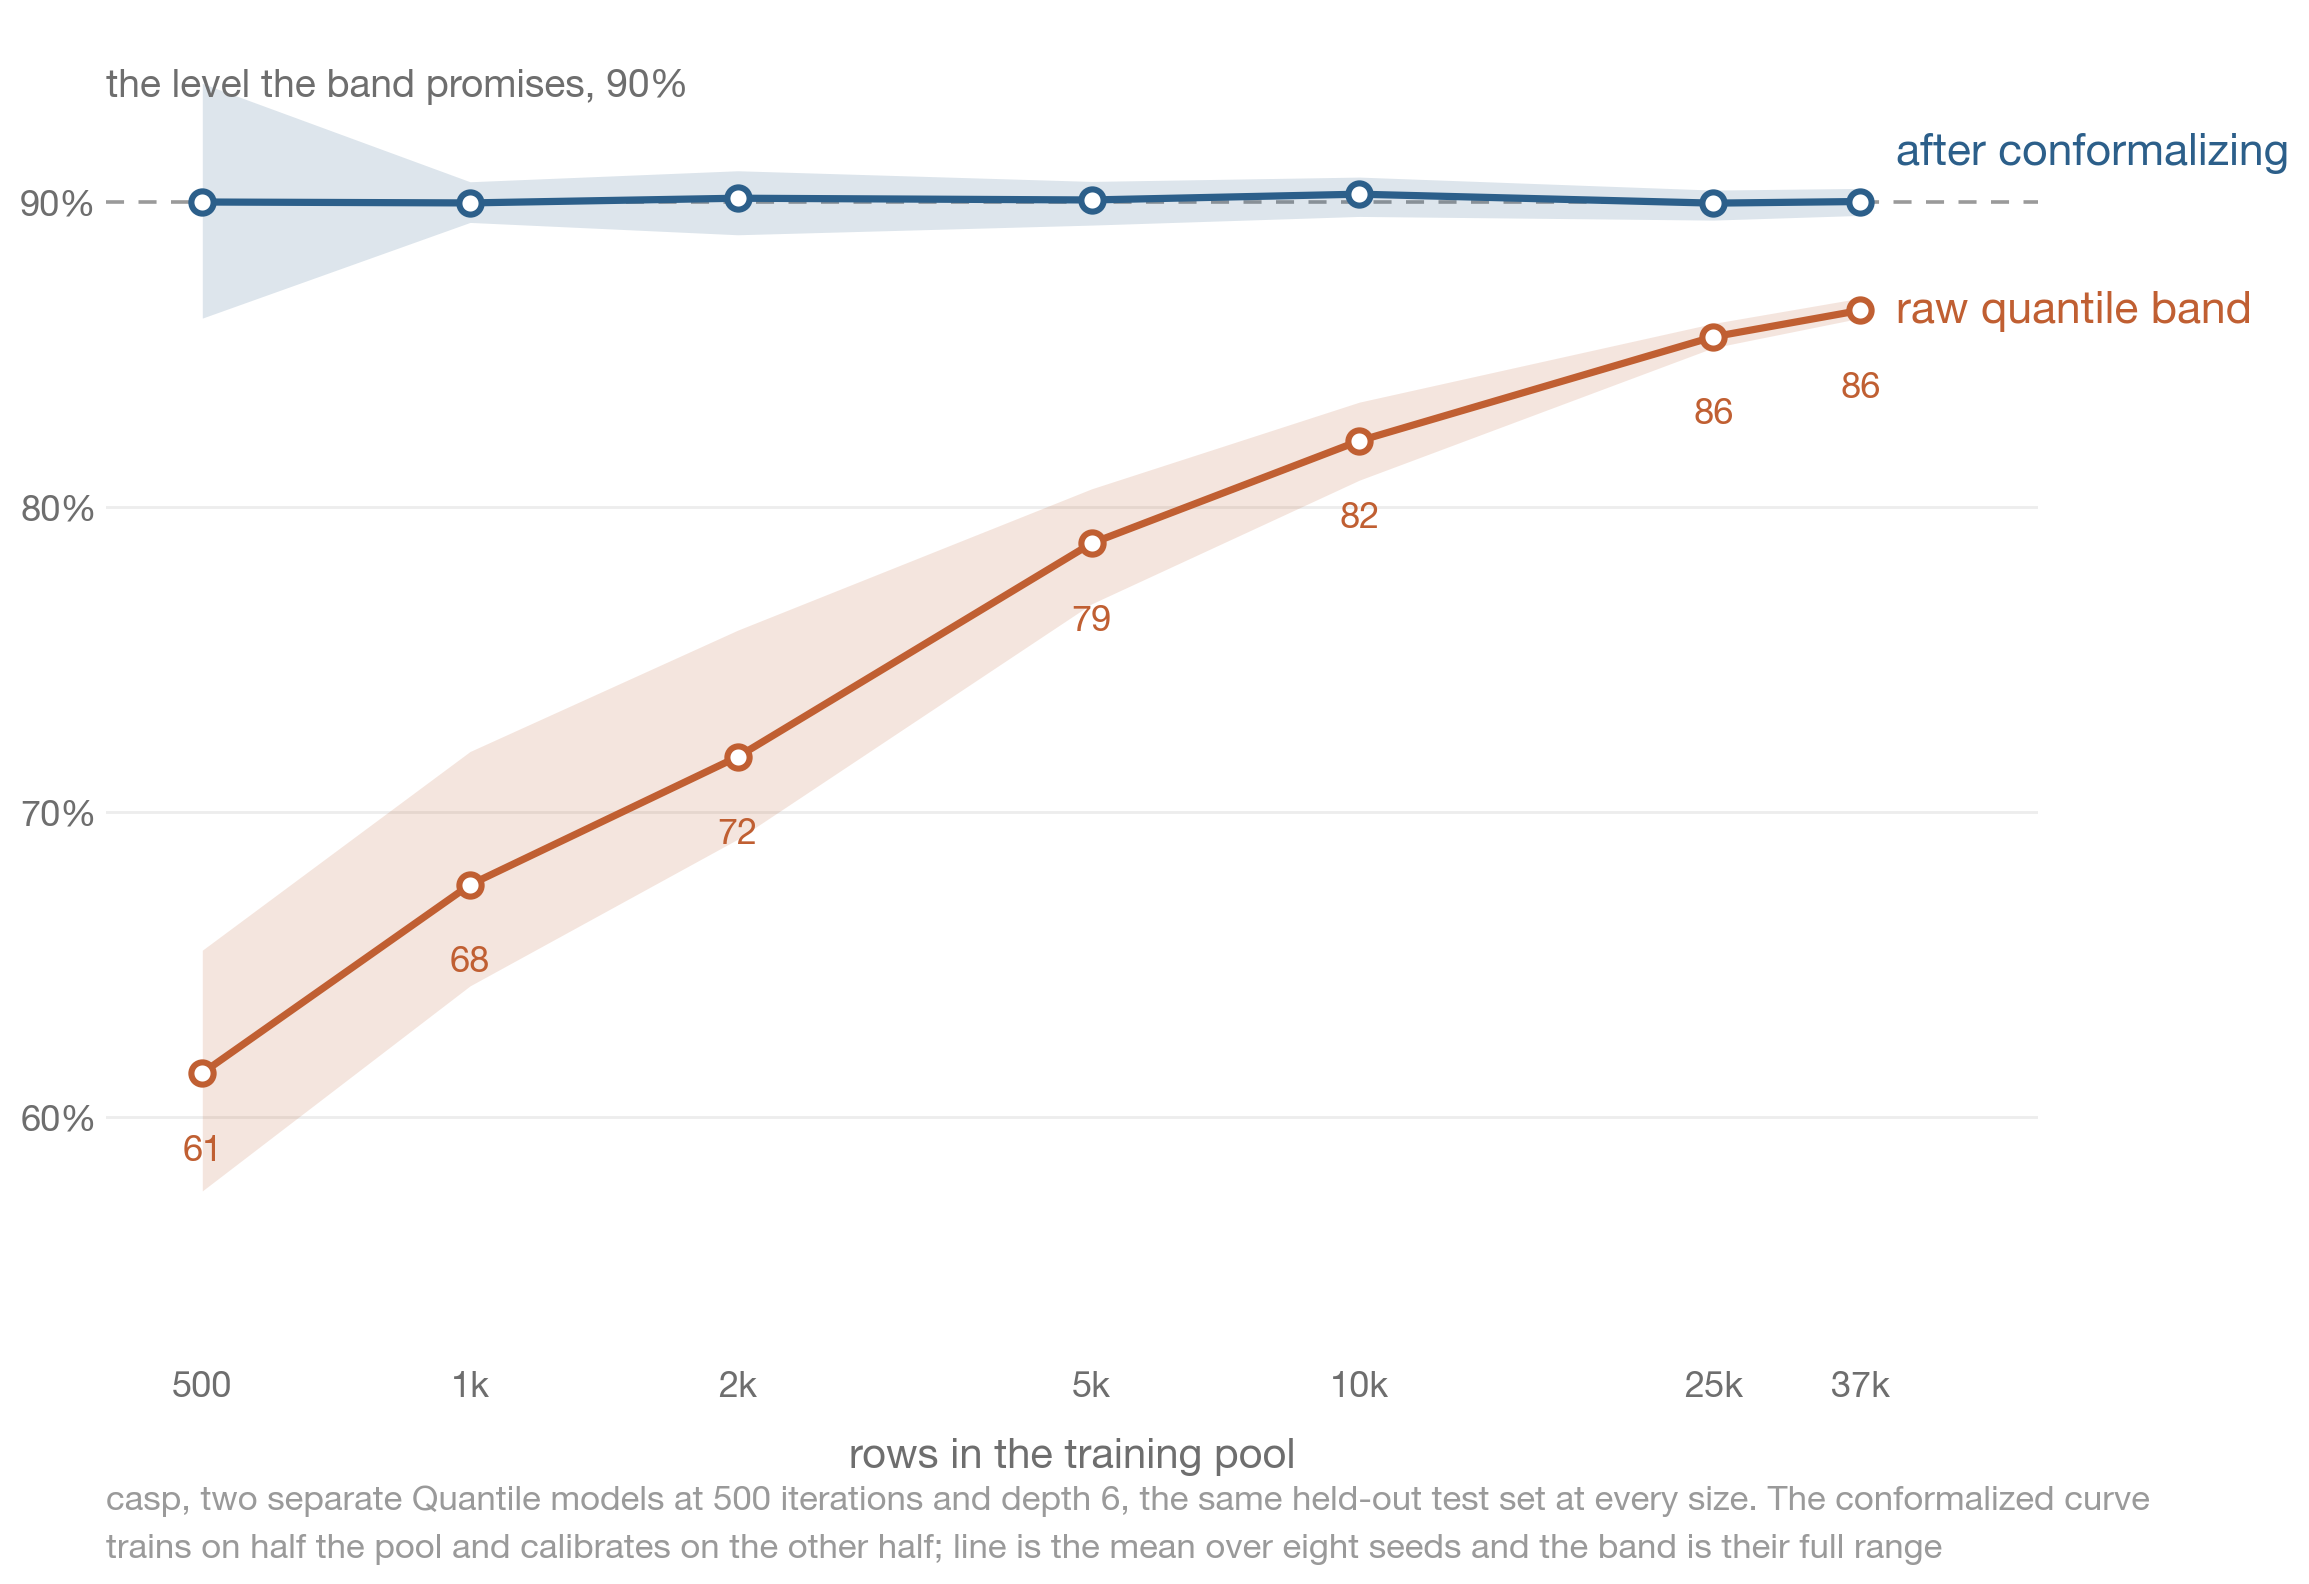

In [12]:
d = size_summary
x = np.log10(d.index.values)
LX, RX = np.log10(390), np.log10(58000)

fig = plt.figure(figsize=(13.8, 8.6), dpi=200)
ax = fig.add_axes([0.075, 0.15, 0.70, 0.78])
ax.set_xlim(LX, RX)
ax.set_ylim(52.0, 96.0)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.tick_params(length=0, labelsize=13, colors=TEXT_MUTED)
for g in (60, 70, 80):
    ax.axhline(g, color="#ededed", lw=1.0, zorder=0)
ax.axhline(90, color="#9a9a9a", lw=1.3, ls=(0, (5, 4)), zorder=1)
ax.text(LX, 93.2, "the level the band promises, 90%", ha="left", va="bottom",
        fontsize=14, color=TEXT_MUTED)
for col, colour, label, dy in (("cqr", BLUE_E, "after conformalizing", 1.6),
                               ("raw", CORAL_E, "raw quantile band", 0.0)):
    ax.fill_between(x, d[(col, "min")], d[(col, "max")], color=colour, alpha=0.16,
                    lw=0, zorder=2)
    ax.plot(x, d[(col, "mean")], "-o", color=colour, lw=2.6, ms=8, zorder=3,
            markerfacecolor="white", markeredgewidth=2.2)
    ax.text(x[-1] + 0.04, d[(col, "mean")].iloc[-1] + dy, label, ha="left", va="center",
            fontsize=16, color=colour)
for xi, v in zip(x, d[("raw", "mean")]):
    ax.text(xi, v - 2.0, f"{v:.0f}", ha="center", va="top", fontsize=13, color=CORAL_E)
ax.set_xticks(x)
ax.set_xticklabels([f"{round(n / 1000)}k" if n >= 1000 else str(n) for n in d.index])
ax.set_yticks([60, 70, 80, 90])
ax.set_yticklabels(["60%", "70%", "80%", "90%"])
ax.set_xlabel("rows in the training pool", fontsize=15, color=TEXT_MUTED, labelpad=12)
fig.text(0.075, 0.055,
         "casp, two separate Quantile models at 500 iterations and depth 6, the same held-out test "
         "set at every size. The conformalized curve\ntrains on half the pool and calibrates on the "
         "other half; line is the mean over eight seeds and the band is their full range",
         ha="left", va="center", fontsize=12.5, color=TEXT_FAINT, linespacing=1.7)
fig.savefig("catboost_quantile_size.png", facecolor="white")
plt.show()

## Ten levels: one model, ten models, and a sort

Two things to compare beyond coverage: whether the quantiles come back in order, and how close
each level lands to the share of rows it promised.

A crossing is a pair of adjacent quantiles that comes out inverted. Sorting each row of predictions
removes crossings by construction, and the rearrangement result of Chernozhukov, Fernandez-Val and
Galichon says it moves the curve no further from the true quantile function. Whether that shows up
in the level error measured on a finite test set is a separate question; the table answers it.

In [13]:
def level_error(p, y, qs):
    return np.abs(100 * (y.values[:, None] <= p).mean(axis=0) - 100 * np.array(qs)).mean()


def crossing(p):
    return 100 * (np.diff(p, axis=1) < 0).any(axis=1).mean()


def timed(strategy, Xtr, ytr, Xte, seed, cfg):
    t = time.perf_counter()
    p = predict_levels(strategy(Xtr, ytr, TEN, seed, cfg), Xte)
    return p, time.perf_counter() - t


grid_rows = []
for name, (X, y) in DATA.items():
    for s in GRID_SEEDS:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=s)
        for cname, cfg in CONFIGS.items():
            pj, tj = timed(fit_joint, Xtr, ytr, Xte, s, cfg)
            ps, ts = timed(fit_separate, Xtr, ytr, Xte, s, cfg)
            grid_rows.append({
                "data": name, "config": cname, "seed": s,
                "one model, crossing %": crossing(pj),
                "ten models, crossing %": crossing(ps),
                "one model, level error": level_error(pj, yte, TEN),
                "ten models, level error": level_error(ps, yte, TEN),
                "one model sorted, level error": level_error(np.sort(pj, axis=1), yte, TEN),
                "ten models sorted, level error": level_error(np.sort(ps, axis=1), yte, TEN),
                "one model, s": tj,
                "ten models, s": ts})
grid_df = pd.DataFrame(grid_rows)
grid_df.drop(columns="seed").groupby(["data", "config"]).mean().round(2)

one model, crossing %  ten models, crossing %  \
data     config                                                        
bike     1000/0.05/d6                  24.33                   71.63   
         300/0.05/d4                   12.19                   54.61   
         500/0.1/d6                    30.43                   84.28   
casp     1000/0.05/d6                  16.14                   51.55   
         300/0.05/d4                    4.28                   24.35   
         500/0.1/d6                    20.11                   65.74   
concrete 1000/0.05/d6                  66.89                   92.72   
         300/0.05/d4                   23.40                   78.74   
         500/0.1/d6                    74.37                   97.09   

                       one model, level error  ten models, level error  \
data     config                                                          
bike     1000/0.05/d6                    3.48                     2.58   
         300/0.05/d4                     0.66                     0.79   
         500/0.1/d6                      3.37                     2.50   
casp     1000/0.05/d6                    1.48                     1.31   
         300/0.05/d4                     0.40                     0.37   
         500/0.1/d6                      1.52                     1.29   
concrete 1000/0.05/d6                   12.43                     9.01   
         300/0.05/d4                     3.97                     3.54   
         500/0.1/d6                     11.81                     8.95   

                       one model sorted, level error  \
data     config                                        
bike     1000/0.05/d6                           3.14   
         300/0.05/d4                            0.62   
         500/0.1/d6                             3.02   
casp     1000/0.05/d6                           1.28   
         300/0.05/d4                            0.37   
         500/0.1/d6                             1.25   
concrete 1000/0.05/d6                           8.98   
         300/0.05/d4                            3.79   
         500/0.1/d6                             8.51   

                       ten models sorted, level error  one model, s  \
data     config                                                       
bike     1000/0.05/d6                            1.73          2.38   
         300/0.05/d4                             0.65          0.49   
         500/0.1/d6                              1.38          1.19   
casp     1000/0.05/d6                            0.72          5.15   
         300/0.05/d4                             0.31          0.99   
         500/0.1/d6                              0.54          2.59   
concrete 1000/0.05/d6                            5.63          1.37   
         300/0.05/d4                             2.86          0.18   
         500/0.1/d6                              4.44          0.68   

                       ten models, s  
data     config                       
bike     1000/0.05/d6           7.14  
         300/0.05/d4            1.72  
         500/0.1/d6             3.57  
casp     1000/0.05/d6          17.63  
         300/0.05/d4            4.19  
         500/0.1/d6             8.88  
concrete 1000/0.05/d6           3.56  
         300/0.05/d4            0.59  
         500/0.1/d6             1.79

In [14]:
best = grid_df.groupby(["data", "config"])[
    ["one model, level error", "ten models sorted, level error"]].mean()
print("mean level error, one MultiQuantile model against ten separate models plus a sort:")
print(best.round(2).to_string())
print()
print(f"ten separate fits plus a sort won in "
      f"{(best.iloc[:, 1] < best.iloc[:, 0]).sum()} of {len(best)} settings")
ratio = grid_df["ten models, s"] / grid_df["one model, s"]
print(f"the joint fit was {ratio.mean():.1f}x faster on average, "
      f"{grid_df['one model, s'].mean():.1f}s against {grid_df['ten models, s'].mean():.1f}s")
cross = grid_df.groupby(["data", "config"])[
    ["one model, crossing %", "ten models, crossing %"]].mean()
print(f"crossings ran {cross.iloc[:, 0].min():.0f}% to {cross.iloc[:, 0].max():.0f}% of rows for "
      f"one model, {cross.iloc[:, 1].min():.0f}% to {cross.iloc[:, 1].max():.0f}% for ten")

mean level error, one MultiQuantile model against ten separate models plus a sort:
                       one model, level error  ten models sorted, level error
data     config                                                              
bike     1000/0.05/d6                    3.48                            1.73
         300/0.05/d4                     0.66                            0.65
         500/0.1/d6                      3.37                            1.38
casp     1000/0.05/d6                    1.48                            0.72
         300/0.05/d4                     0.40                            0.31
         500/0.1/d6                      1.52                            0.54
concrete 1000/0.05/d6                   12.43                            5.63
         300/0.05/d4                     3.97                            2.86
         500/0.1/d6                     11.81                            4.44

ten separate fits plus a sort won in 9 of 9 settings
the j

## Takeaway

The nominal level is a fitting target. On held-out rows every seed-averaged band here came in under
it, and how hard the trees were fitted mattered more than which of the three arms produced the
band.

`MultiQuantile` is a real saving when a whole grid of levels is wanted, and it crossed on 4% to 74%
of rows against 24% to 97% for separate fits. Part of the saving is that it builds one ensemble
where the separate fits build ten, which is also why its outer levels give way first once the fit is
hard. It is not the best answer to crossing either: sorting each row removes crossings outright and
lands the individual levels closer than joint fitting does.

Conformalizing is the only step here that put the band on the level it claimed, down to a pool of
500 rows. It costs the calibration rows, and cross-conformal variants exist to avoid paying that in
one lump.

One limit worth repeating: conformal coverage is marginal. It holds over the test set as a whole
and says nothing about any particular slice of it. No arm here used early stopping or a tuned
validation set either, so read the harder settings as deliberately over-fitted rather than as
advice.